In [1]:
import os 
from dotenv import load_dotenv 
load_dotenv()

from langchain.chat_models import init_chat_model
api_key = os.getenv("GOOGLE_API_KEY")

model= init_chat_model (
    "google_genai:gemini-flash-latest", 
    api_key=api_key,
    temperature=0.7
)


d:\langgraphcourse\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv

from langchain_core.messages import RemoveMessage

In [4]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [6]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [7]:
graph = builder.compile(checkpointer=InMemorySaver())

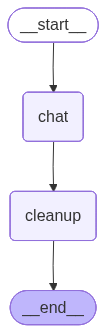

In [8]:
graph

In [9]:
config = {"configurable": {"thread_id": "t1"}}

In [10]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Basant"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='39a385d6-23d4-44bd-98ea-d4b4df8e9b8b'),
  AIMessage(content='Since we started with **LangGraph**, it’s helpful to think of **LangChain** as the foundation or the "toolbox" that LangGraph is built upon.\n\n**LangChain** is an open-source framework designed to make it easier for developers to build applications powered by Large Language Models (LLMs). \n\nIf an LLM (like GPT-4) is the "brain," LangChain is the **body**—it provides the hands to use tools, the memory to remember past conversations, and the pipes to connect different data sources.\n\nHere are the four main things LangChain does:\n\n### 1. Standardizing the Interface\nThere are many LLM providers (OpenAI, Anthropic, Google, Meta, etc.). Each has a different way of being called. \n*   **LangChain\'s Solution:** It provides a unified syntax. You can write your code once, and then easily swap out GPT-4 for Claude or Llama-3 b

In [11]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
